In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("D:\\Assignments questions\\blogs.csv")   # your uploaded file
print(df.head())

# Check shape and null values
print("Shape of dataset:", df.shape)
print("Null values:\n", df.isnull().sum())

# Check distribution of categories
print("Category distribution:\n", df['Labels'].value_counts())


                                                Data       Labels
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  alt.atheism
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  alt.atheism
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  alt.atheism
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  alt.atheism
Shape of dataset: (2000, 2)
Null values:
 Data      0
Labels    0
dtype: int64
Category distribution:
 Labels
alt.atheism                 100
comp.graphics               100
comp.os.ms-windows.misc     100
comp.sys.ibm.pc.hardware    100
comp.sys.mac.hardware       100
comp.windows.x              100
misc.forsale                100
rec.autos                   100
rec.motorcycles             100
rec.sport.baseball          100
rec.sport.hockey            100
sci.crypt                   100
sci.electronics             100
sci.med                     100
sci.space                   100
soc.religion.c

In [3]:
import re
import nltk
from nltk.corpus import stopwords

# Download stopwords (run once)
nltk.download("stopwords")
stop_words = set(stopwords.words("english"))

# Text cleaning function
def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove punctuation/numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = text.split()
    # Remove stopwords
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

# Apply cleaning
df["Cleaned_Text"] = df["Data"].astype(str).apply(clean_text)

print(df[["Data", "Cleaned_Text"]].head())


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\munig\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                Data  \
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...   
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....   
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...   
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...   
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...   

                                        Cleaned_Text  
0  path cantaloupesrvcscmuedumagnesiumclubcccmued...  
1  newsgroups altatheism path cantaloupesrvcscmue...  
2  path cantaloupesrvcscmuedudasnewsharvardedunoc...  
3  path cantaloupesrvcscmuedumagnesiumclubcccmued...  
4  xref cantaloupesrvcscmuedu altatheism talkreli...  


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF vectorizer
tfidf = TfidfVectorizer(max_features=5000)   # limit features for efficiency
X = tfidf.fit_transform(df["Cleaned_Text"]).toarray()
y = df["Labels"]

print("TF-IDF shape:", X.shape)


TF-IDF shape: (2000, 5000)


In [5]:
from sklearn.model_selection import train_test_split

# X = features from TF-IDF, y = labels (categories)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)


Training set size: (1600, 5000)
Test set size: (400, 5000)


In [6]:
from sklearn.naive_bayes import MultinomialNB

# Initialize model
nb_model = MultinomialNB()

# Train on training data
nb_model.fit(X_train, y_train)


,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [7]:
# Predict categories on test data
y_pred = nb_model.predict(X_test)

print("Sample predictions:", y_pred[:10])


Sample predictions: ['sci.crypt' 'sci.med' 'talk.politics.mideast' 'soc.religion.christian'
 'talk.politics.guns' 'sci.med' 'comp.windows.x' 'rec.motorcycles'
 'talk.politics.mideast' 'comp.graphics']


In [8]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Download vader lexicon (run once)
nltk.download("vader_lexicon")

# Initialize sentiment analyzer
sia = SentimentIntensityAnalyzer()


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\munig\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [9]:
def get_sentiment(text):
    score = sia.polarity_scores(str(text))["compound"]
    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment function
df["Sentiment"] = df["Data"].apply(get_sentiment)

print(df[["Data", "Sentiment"]].head())


                                                Data Sentiment
0  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Negative
1  Newsgroups: alt.atheism\nPath: cantaloupe.srv....  Positive
2  Path: cantaloupe.srv.cs.cmu.edu!das-news.harva...  Negative
3  Path: cantaloupe.srv.cs.cmu.edu!magnesium.club...  Negative
4  Xref: cantaloupe.srv.cs.cmu.edu alt.atheism:53...  Positive


In [10]:
# Count overall sentiment distribution
print("Overall sentiment distribution:\n", df["Sentiment"].value_counts())


Overall sentiment distribution:
 Sentiment
Positive    1334
Negative     631
Neutral       35
Name: count, dtype: int64


Sentiment                 Negative  Neutral  Positive
Labels                                               
alt.atheism                     42        1        57
comp.graphics                   13        4        83
comp.os.ms-windows.misc         24        2        74
comp.sys.ibm.pc.hardware        21        0        79
comp.sys.mac.hardware           24        3        73
comp.windows.x                  20        2        78
misc.forsale                     7        8        85
rec.autos                       27        1        72
rec.motorcycles                 30        2        68
rec.sport.baseball              27        1        72
rec.sport.hockey                28        1        71
sci.crypt                       29        0        71
sci.electronics                 18        4        78
sci.med                         38        1        61
sci.space                       32        3        65
soc.religion.christian          29        0        71
talk.politics.guns          

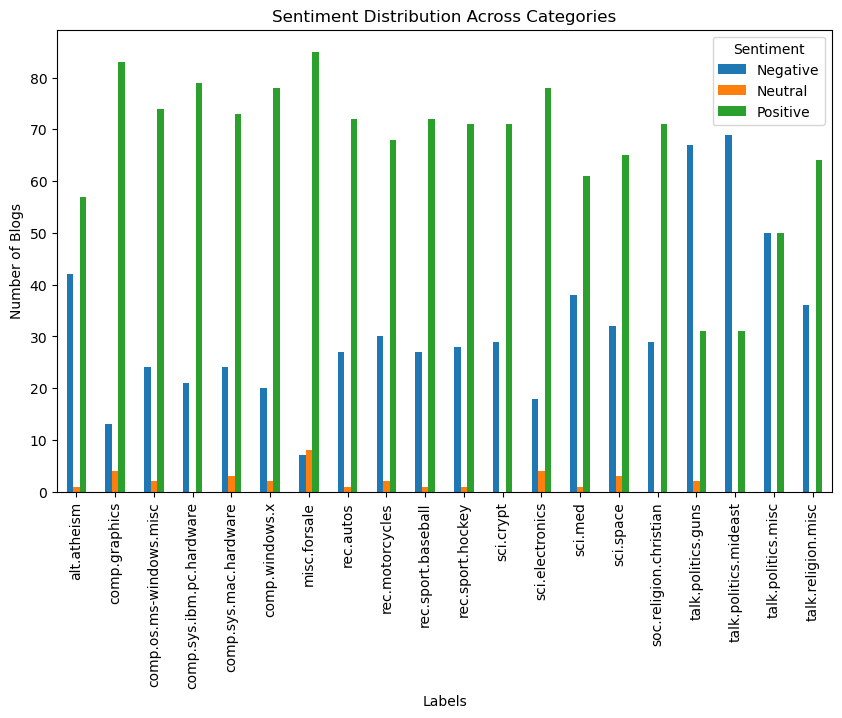

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Crosstab for sentiment across categories
sentiment_category = pd.crosstab(df["Labels"], df["Sentiment"])

print(sentiment_category)

# Visualization
sentiment_category.plot(kind="bar", figsize=(10,6))
plt.title("Sentiment Distribution Across Categories")
plt.ylabel("Number of Blogs")
plt.show()
